# TFG: Detección precoz de cáncer colorrectal utilizando técnicas de aprendizaje automático
**Grado en Física - Universidad Europea de Valencia**

* **Presentado por:** Gabriela Hortensia Ramos Mizrachi
* **Tutor:** Héctor Gisbert Mullor
* **Curso:** 2025-2026

---
### Resumen del Notebook
Este notebook documenta el proceso experimental en el cual se prueba el modelo de aprendizaje automatico, específicamente el análisis de las correlaciones entre diferentes variables de los datos.

# Etapa 2: Optimización mediante aprendizaje automático: 
## Análisis de correlaciones

### Importación de Librerías y Dependencias
En esta sección se cargan todas las herramientas necesarias para el proyecto:

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, HTML

### Procesamiento de Poblaciones (M, S, P) y Cálculo de Correlaciones
En esta celda se realiza el flujo principal de procesamiento de datos para tres poblaciones distintas:

**Población 'M' (Modelo/Control):** - Lee archivos `.xlsx` que comienzan con "M".
   - Localiza la sección de datos bajo el encabezado 'Library/ID'.
   - Extrae y limpia los nombres de la quinta columna.
   - Identifica los 25 nombres más frecuentes para definir las variables principales.
   - Crea una tabla pivote y calcula la **matriz de correlación** para esta población.

**Población 'S' y 'P':**
   - Repite el proceso de extracción para archivos que comienzan con "S (" y "P (".
   - Filtra los datos para mantener únicamente los mismos 25 nombres principales identificados en la población 'M'.
   - Genera sus respectivas matrices de correlación.

In [3]:
# ------------------------ Procesar Población 'M' ------------------------
# Inicializar DataFrame para la población M
all_counts_m = pd.DataFrame()

# Procesar archivos 'M'
for file_name in os.listdir():
    if file_name.startswith('M (') and file_name.endswith('.xlsx'):
        df = pd.read_excel(file_name, sheet_name=0)

        # Encontrar la fila que contiene 'Library/ID'
        library_id_rows = df.apply(lambda row: row.astype(str).str.contains('Library/ID', case=False, na=False)).any(axis=1)
        library_id_index = library_id_rows[library_id_rows == True].index[0]

        # Extraer filas debajo del encabezado 'Library/ID'
        names_data = df.iloc[library_id_index + 1:, :]
        name_column = names_data.iloc[:, 4]  # Asumiendo que la 5ta columna tiene los nombres

        # Obtener nombres únicos y contar cada uno como 1 por archivo
        unique_names = pd.DataFrame({'Name': name_column.unique(), 'Count': 1})
        unique_names['File'] = file_name

        # Añadir al DataFrame principal
        all_counts_m = pd.concat([all_counts_m, unique_names], ignore_index=True)

# Limpiar nombres en 'M'
all_counts_m['Name'] = all_counts_m['Name'].fillna('').astype(str).apply(lambda x: x.split('$$')[0].strip())

# Agregar conteos para 'M'
grouped_m = all_counts_m.groupby(['File', 'Name'])['Count'].sum().reset_index()

# Obtener los 25 nombres más frecuentes para 'M'
top_names_m = grouped_m.groupby('Name')['Count'].sum().nlargest(25).index

# Tabla pivote para 'M'
pivot_m = grouped_m[grouped_m['Name'].isin(top_names_m)].pivot(index='File', columns='Name', values='Count').fillna(0)

# Matriz de correlación para 'M'
correlation_matrix_m = pivot_m.corr()

# ------------------------ Procesar Población 'S' ------------------------
# Inicializar DataFrame para la población S
all_counts_s = pd.DataFrame()

# Procesar archivos 'S'
for file_name in os.listdir():
    if file_name.startswith('S (') and file_name.endswith('.xlsx'):
        df = pd.read_excel(file_name, sheet_name=0)

        # Encontrar la fila que contiene 'Library/ID'
        library_id_rows = df.apply(lambda row: row.astype(str).str.contains('Library/ID', case=False, na=False)).any(axis=1)
        library_id_index = library_id_rows[library_id_rows == True].index[0]

        # Extraer filas debajo del encabezado 'Library/ID'
        names_data = df.iloc[library_id_index + 1:, :]
        name_column = names_data.iloc[:, 4]  # Asumiendo que la 5ta columna tiene los nombres

        # Obtener nombres únicos y contar cada uno como 1 por archivo
        unique_names = pd.DataFrame({'Name': name_column.unique(), 'Count': 1})
        unique_names['File'] = file_name

        # Añadir al DataFrame principal
        all_counts_s = pd.concat([all_counts_s, unique_names], ignore_index=True)

# Limpiar nombres en 'S'
all_counts_s['Name'] = all_counts_s['Name'].fillna('').astype(str).apply(lambda x: x.split('$$')[0].strip())

# Agregar conteos para 'S'
grouped_s = all_counts_s.groupby(['File', 'Name'])['Count'].sum().reset_index()

# Filtrar 'S' para mantener solo los nombres principales de 'M'
pivot_s = grouped_s[grouped_s['Name'].isin(top_names_m)].pivot(index='File', columns='Name', values='Count').fillna(0)

# Matriz de correlación para 'S'
correlation_matrix_s = pivot_s.corr()

# ------------------------ Procesar Población 'P' ------------------------
# Inicializar DataFrame para la población P
all_counts_p = pd.DataFrame()

# Procesar archivos 'P'
for file_name in os.listdir():
    if file_name.startswith('P (') and file_name.endswith('.xlsx'):
        df = pd.read_excel(file_name, sheet_name=0)

        # Encontrar la fila que contiene 'Library/ID'
        library_id_rows = df.apply(lambda row: row.astype(str).str.contains('Library/ID', case=False, na=False)).any(axis=1)
        library_id_index = library_id_rows[library_id_rows == True].index[0]

        # Extraer filas debajo del encabezado 'Library/ID'
        names_data = df.iloc[library_id_index + 1:, :]
        name_column = names_data.iloc[:, 4]  # Asumiendo que la 5ta columna tiene los nombres

        # Obtener nombres únicos y contar cada uno como 1 por archivo
        unique_names = pd.DataFrame({'Name': name_column.unique(), 'Count': 1})
        unique_names['File'] = file_name

        # Añadir al DataFrame principal
        all_counts_p = pd.concat([all_counts_p, unique_names], ignore_index=True)

# Limpiar nombres en 'P'
all_counts_p['Name'] = all_counts_p['Name'].fillna('').astype(str).apply(lambda x: x.split('$$')[0].strip())

# Agregar conteos para 'P'
grouped_p = all_counts_p.groupby(['File', 'Name'])['Count'].sum().reset_index()

# Filtrar 'P' para mantener solo los nombres principales de 'M'
pivot_p = grouped_p[grouped_p['Name'].isin(top_names_m)].pivot(index='File', columns='Name', values='Count').fillna(0)

# Matriz de correlación para 'P'
correlation_matrix_p = pivot_p.corr()

# ------------------------ Calcular Diferencias ------------------------
# Calcular la diferencia entre las matrices de correlación
correlation_diff = correlation_matrix_m - correlation_matrix_s
correlation_diff_M_P = correlation_matrix_m - correlation_matrix_p
correlation_diff_S_P = correlation_matrix_s - correlation_matrix_p

### Visualización de la Matriz de Correlación (Población M)

Se genera un **mapa de calor (heatmap)** para visualizar las relaciones entre las variables de la población (M).

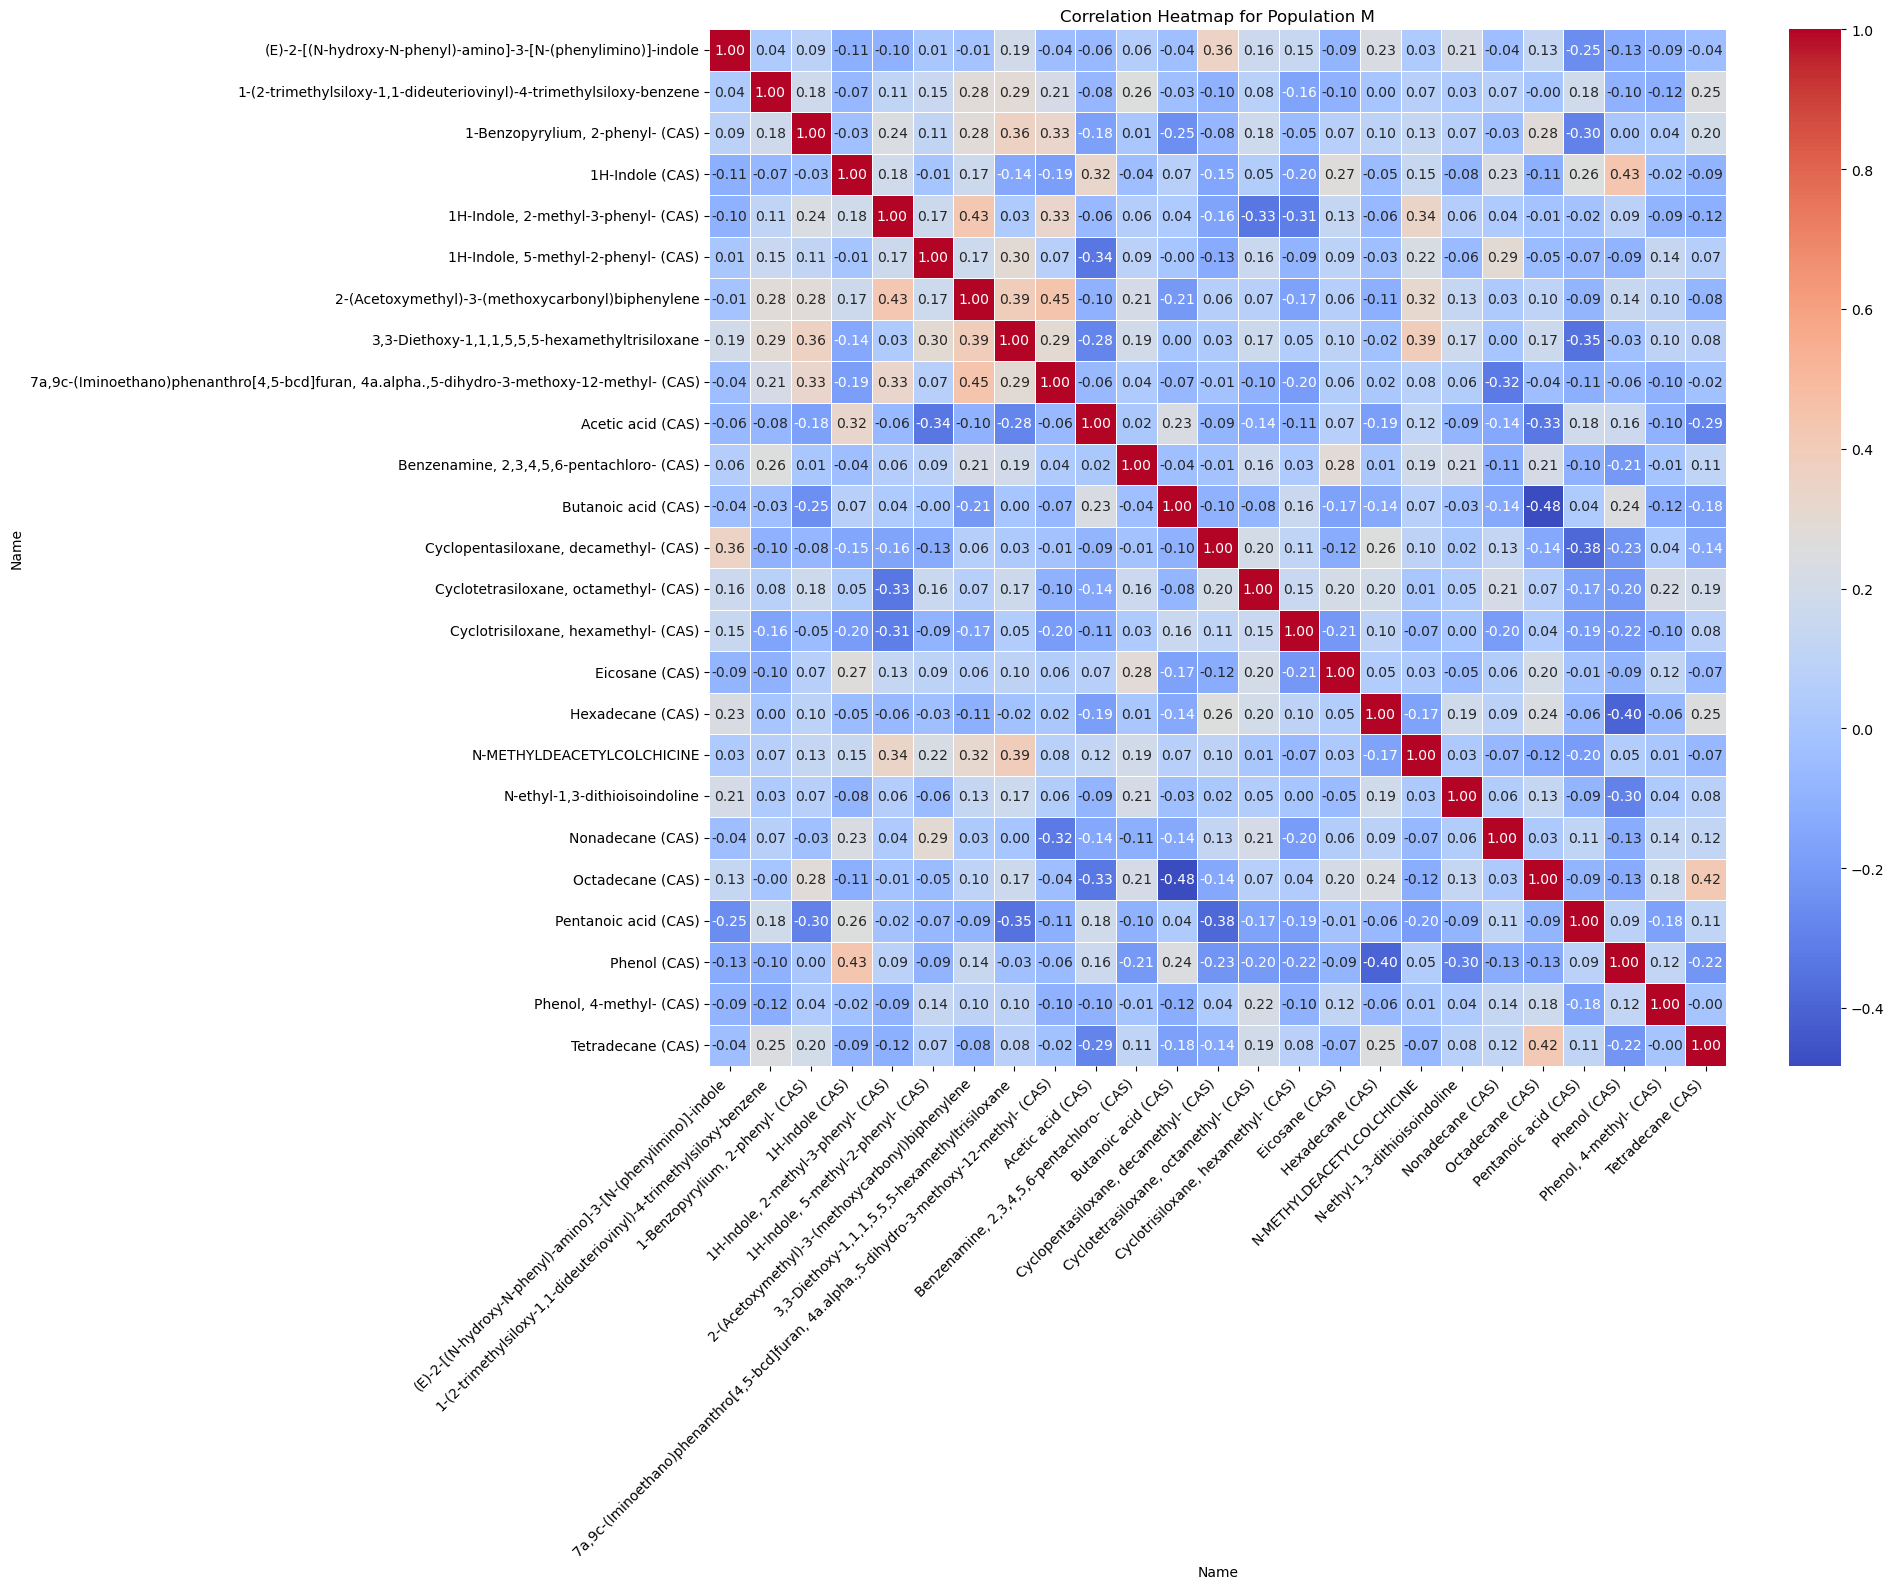

In [4]:
# ------------------------ Plot del Heatmaps ------------------------

# Heatmap para 'M'
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix_m, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap for Population M')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualización de la Matriz de Correlación (Población s)

Se genera un **mapa de calor (heatmap)** para visualizar las relaciones entre las variables de la población de control (S).

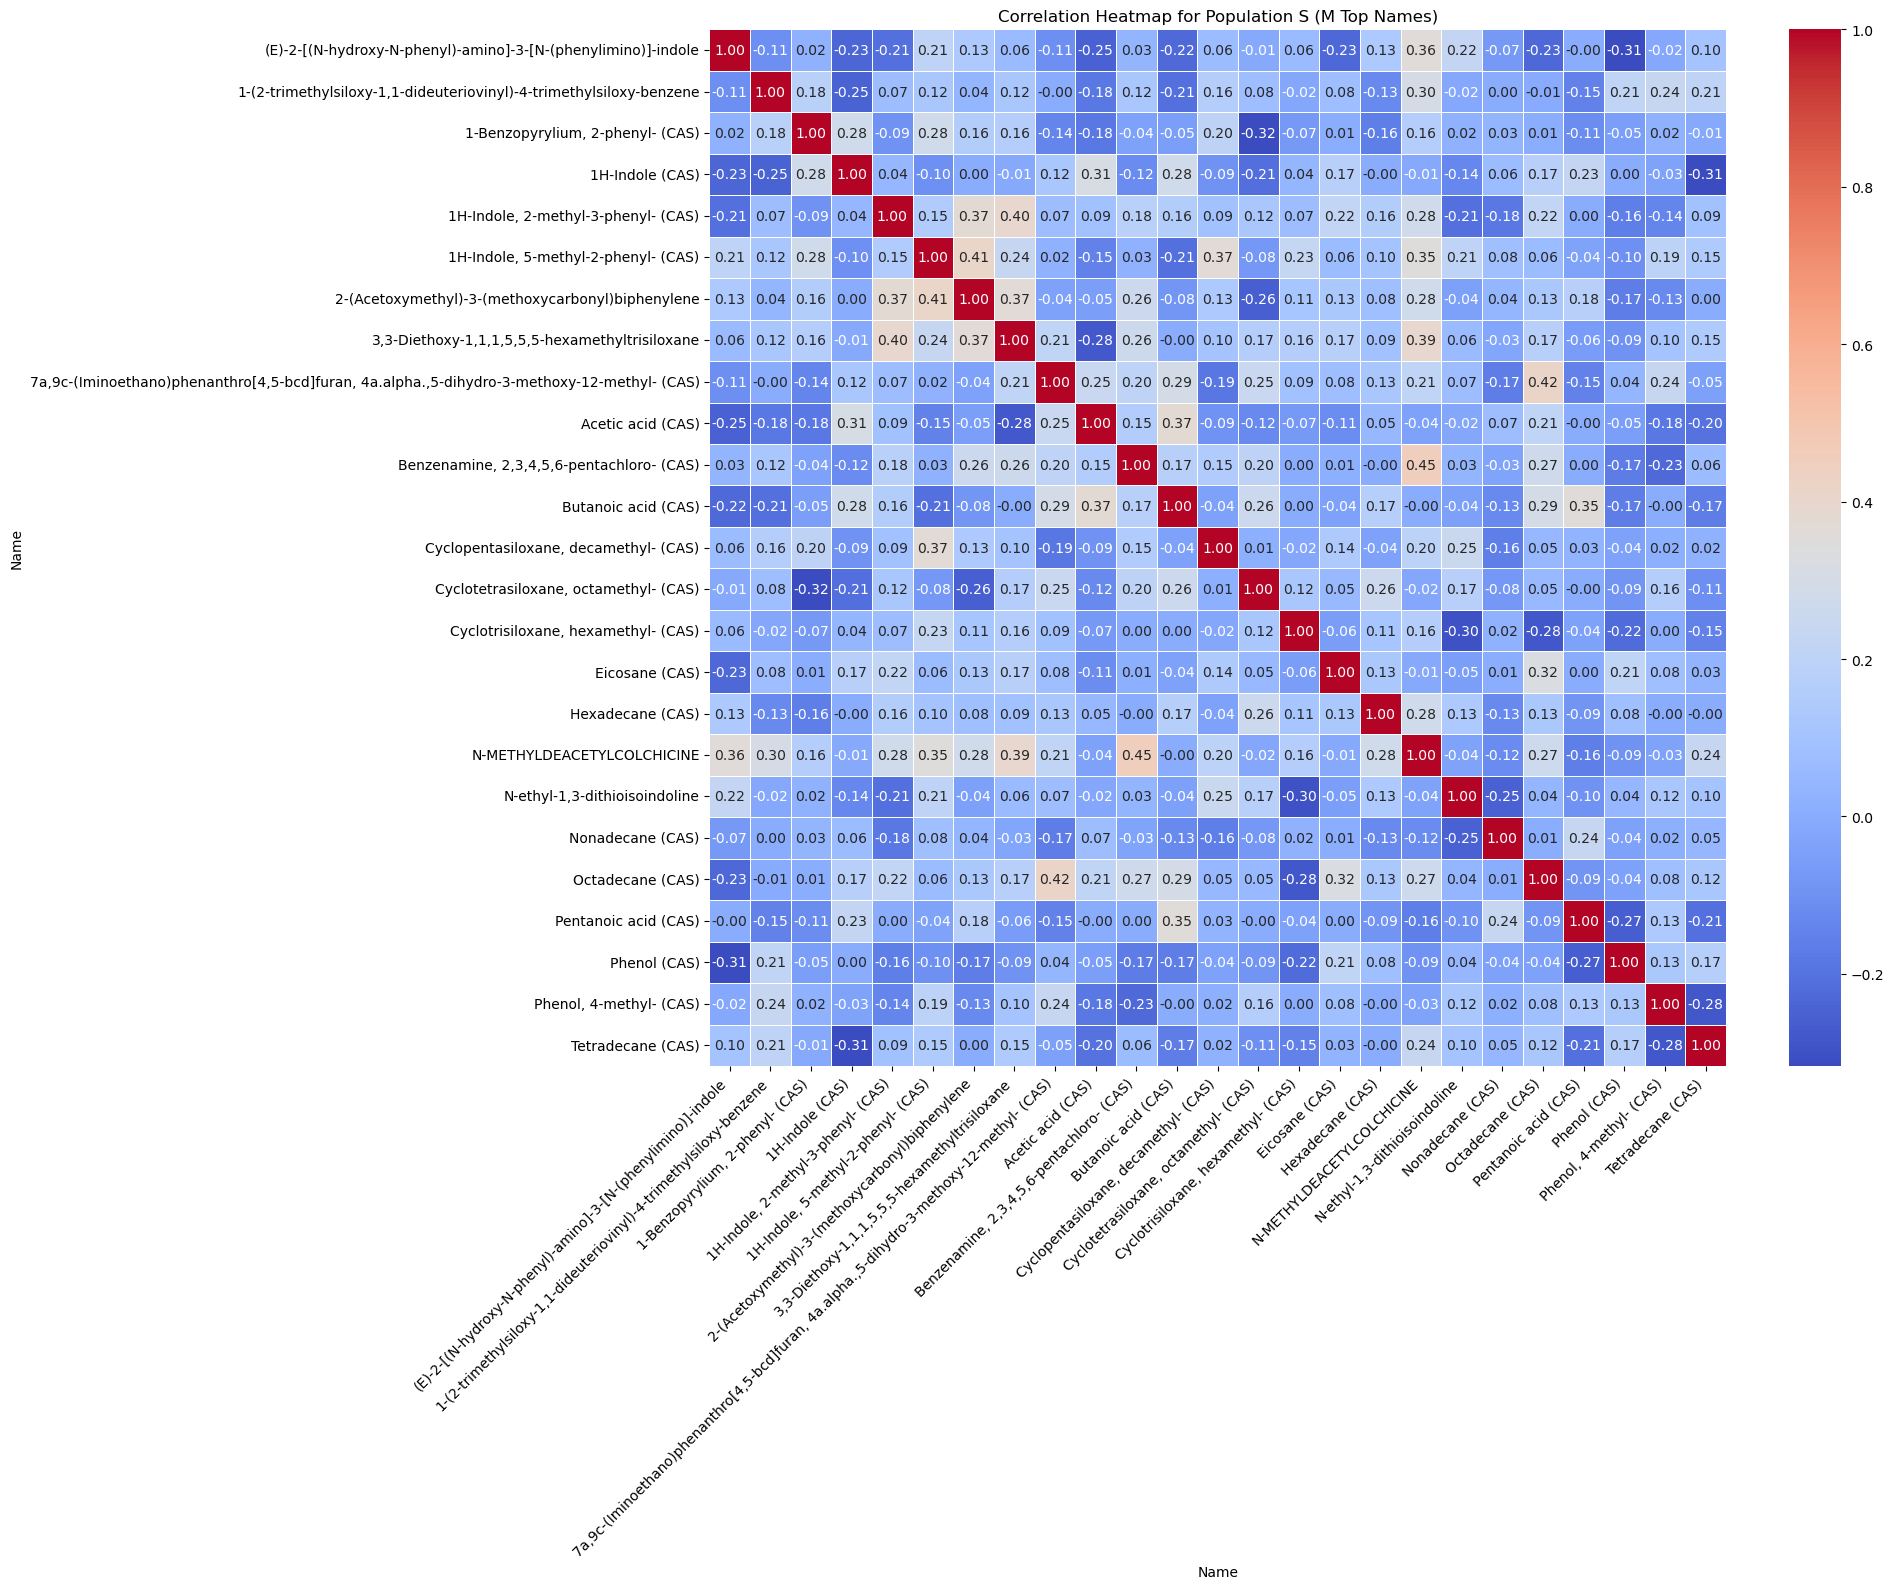

In [5]:
# Heatmap para 'S'
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix_s, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap for Population S (M Top Names)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualización de la Matriz de Correlación (Población P)

Se genera un **mapa de calor (heatmap)** para visualizar las relaciones entre las variables de la población de control (P).

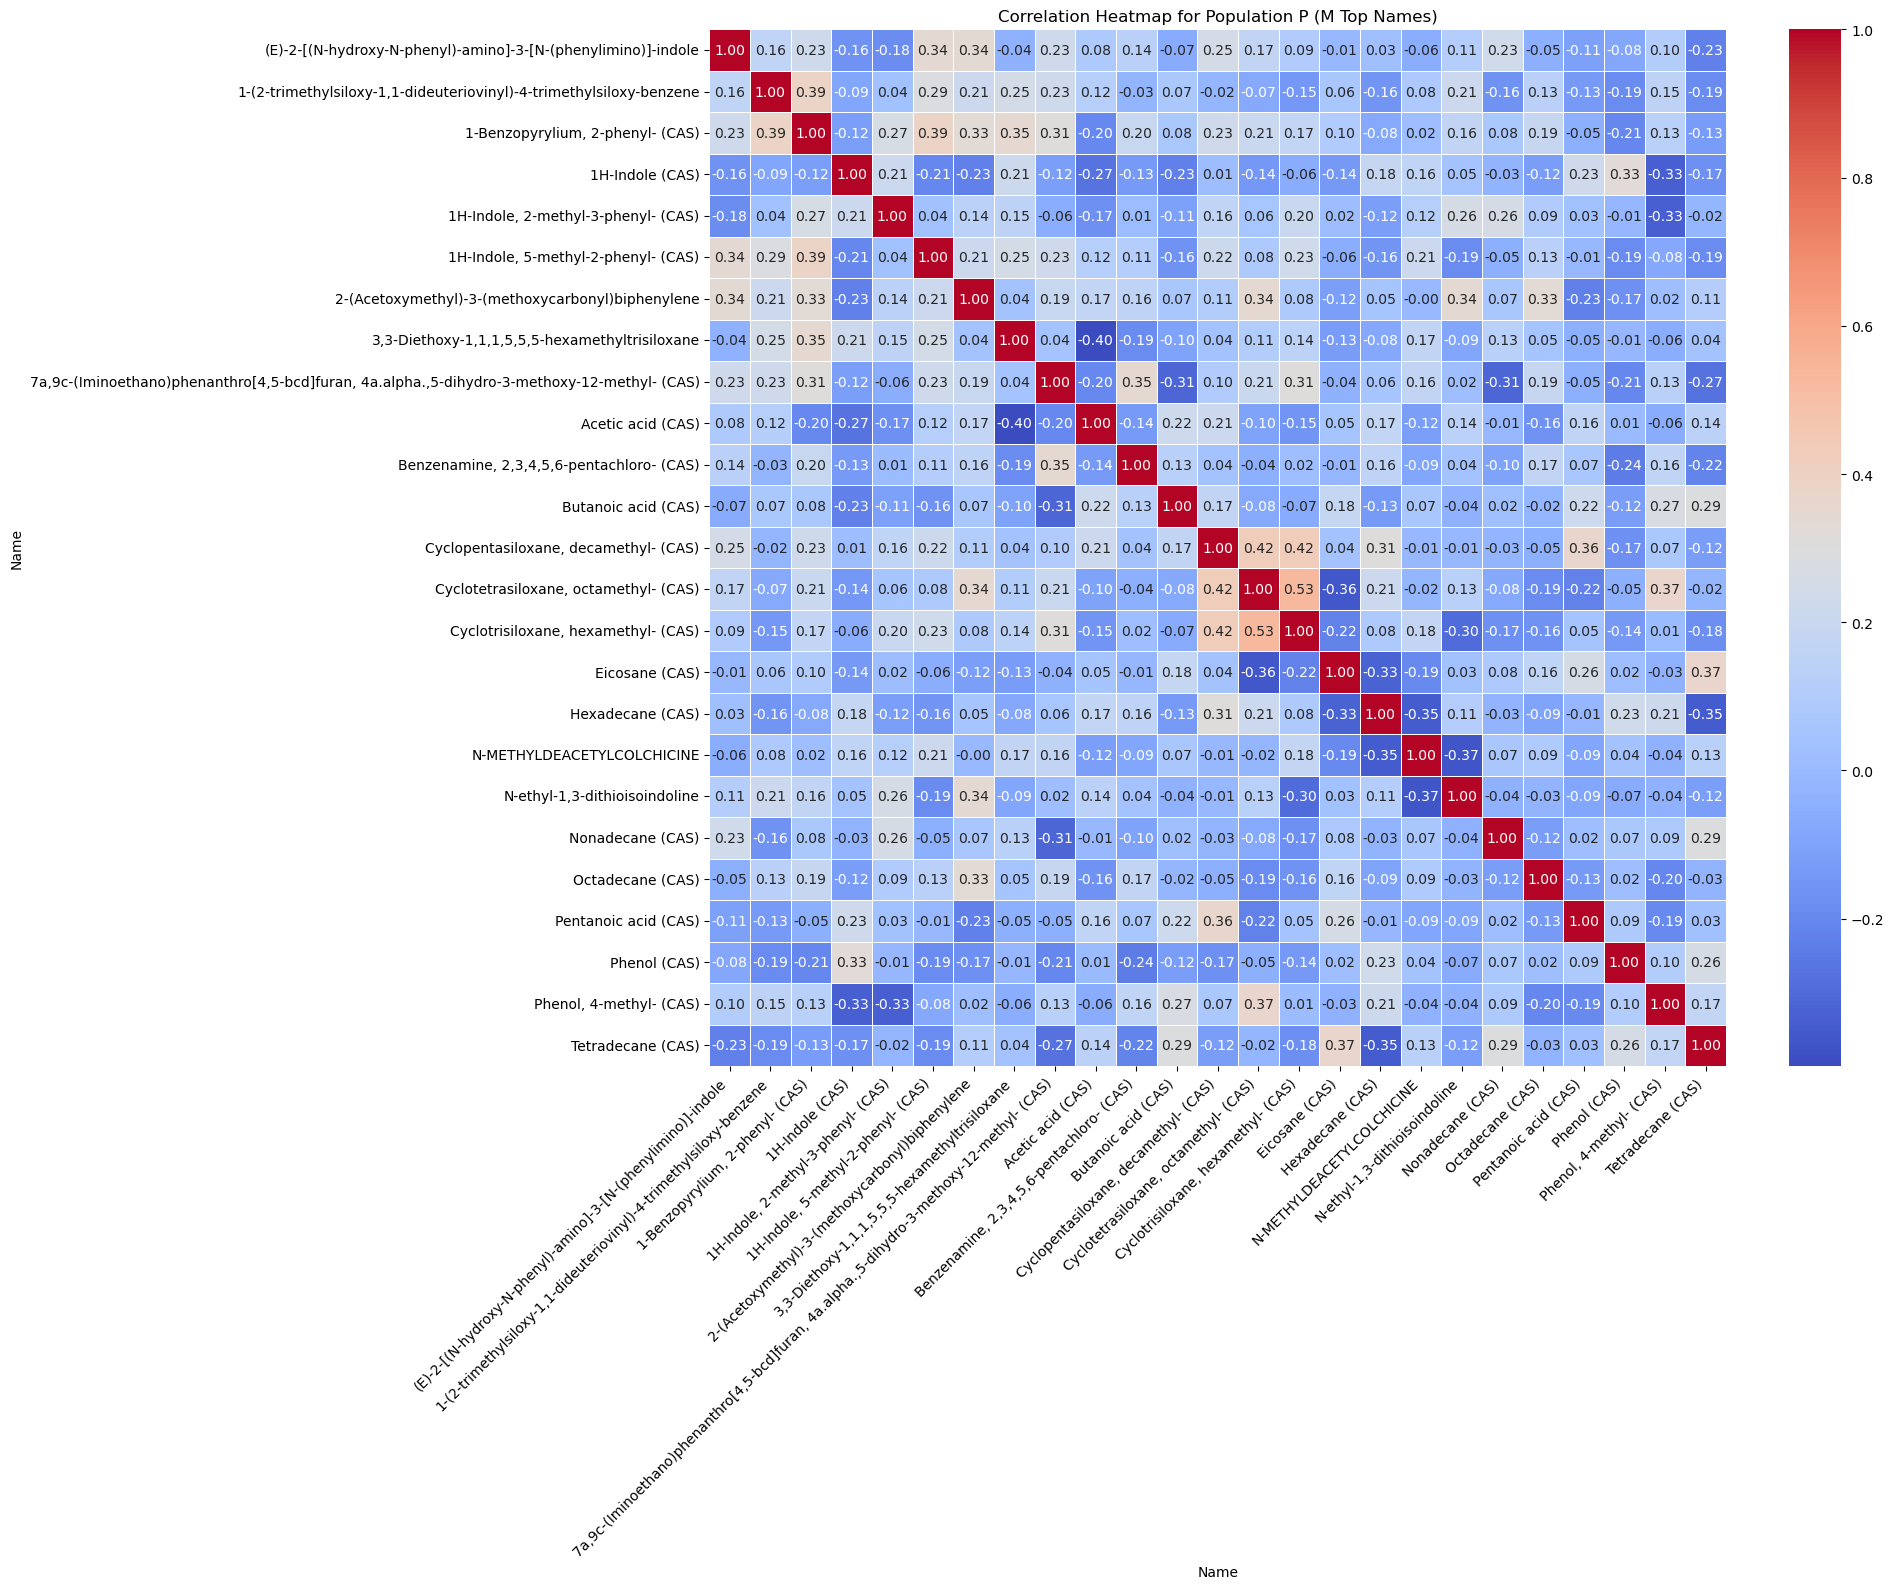

In [6]:
# Heatmap para 'P'
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix_p, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap for Population P (M Top Names)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Diferencias de Correlación diferencia entre S - M
Esta celda genera mapas de calor (heatmaps) para visualizar las diferencias calculadas anteriormente. 

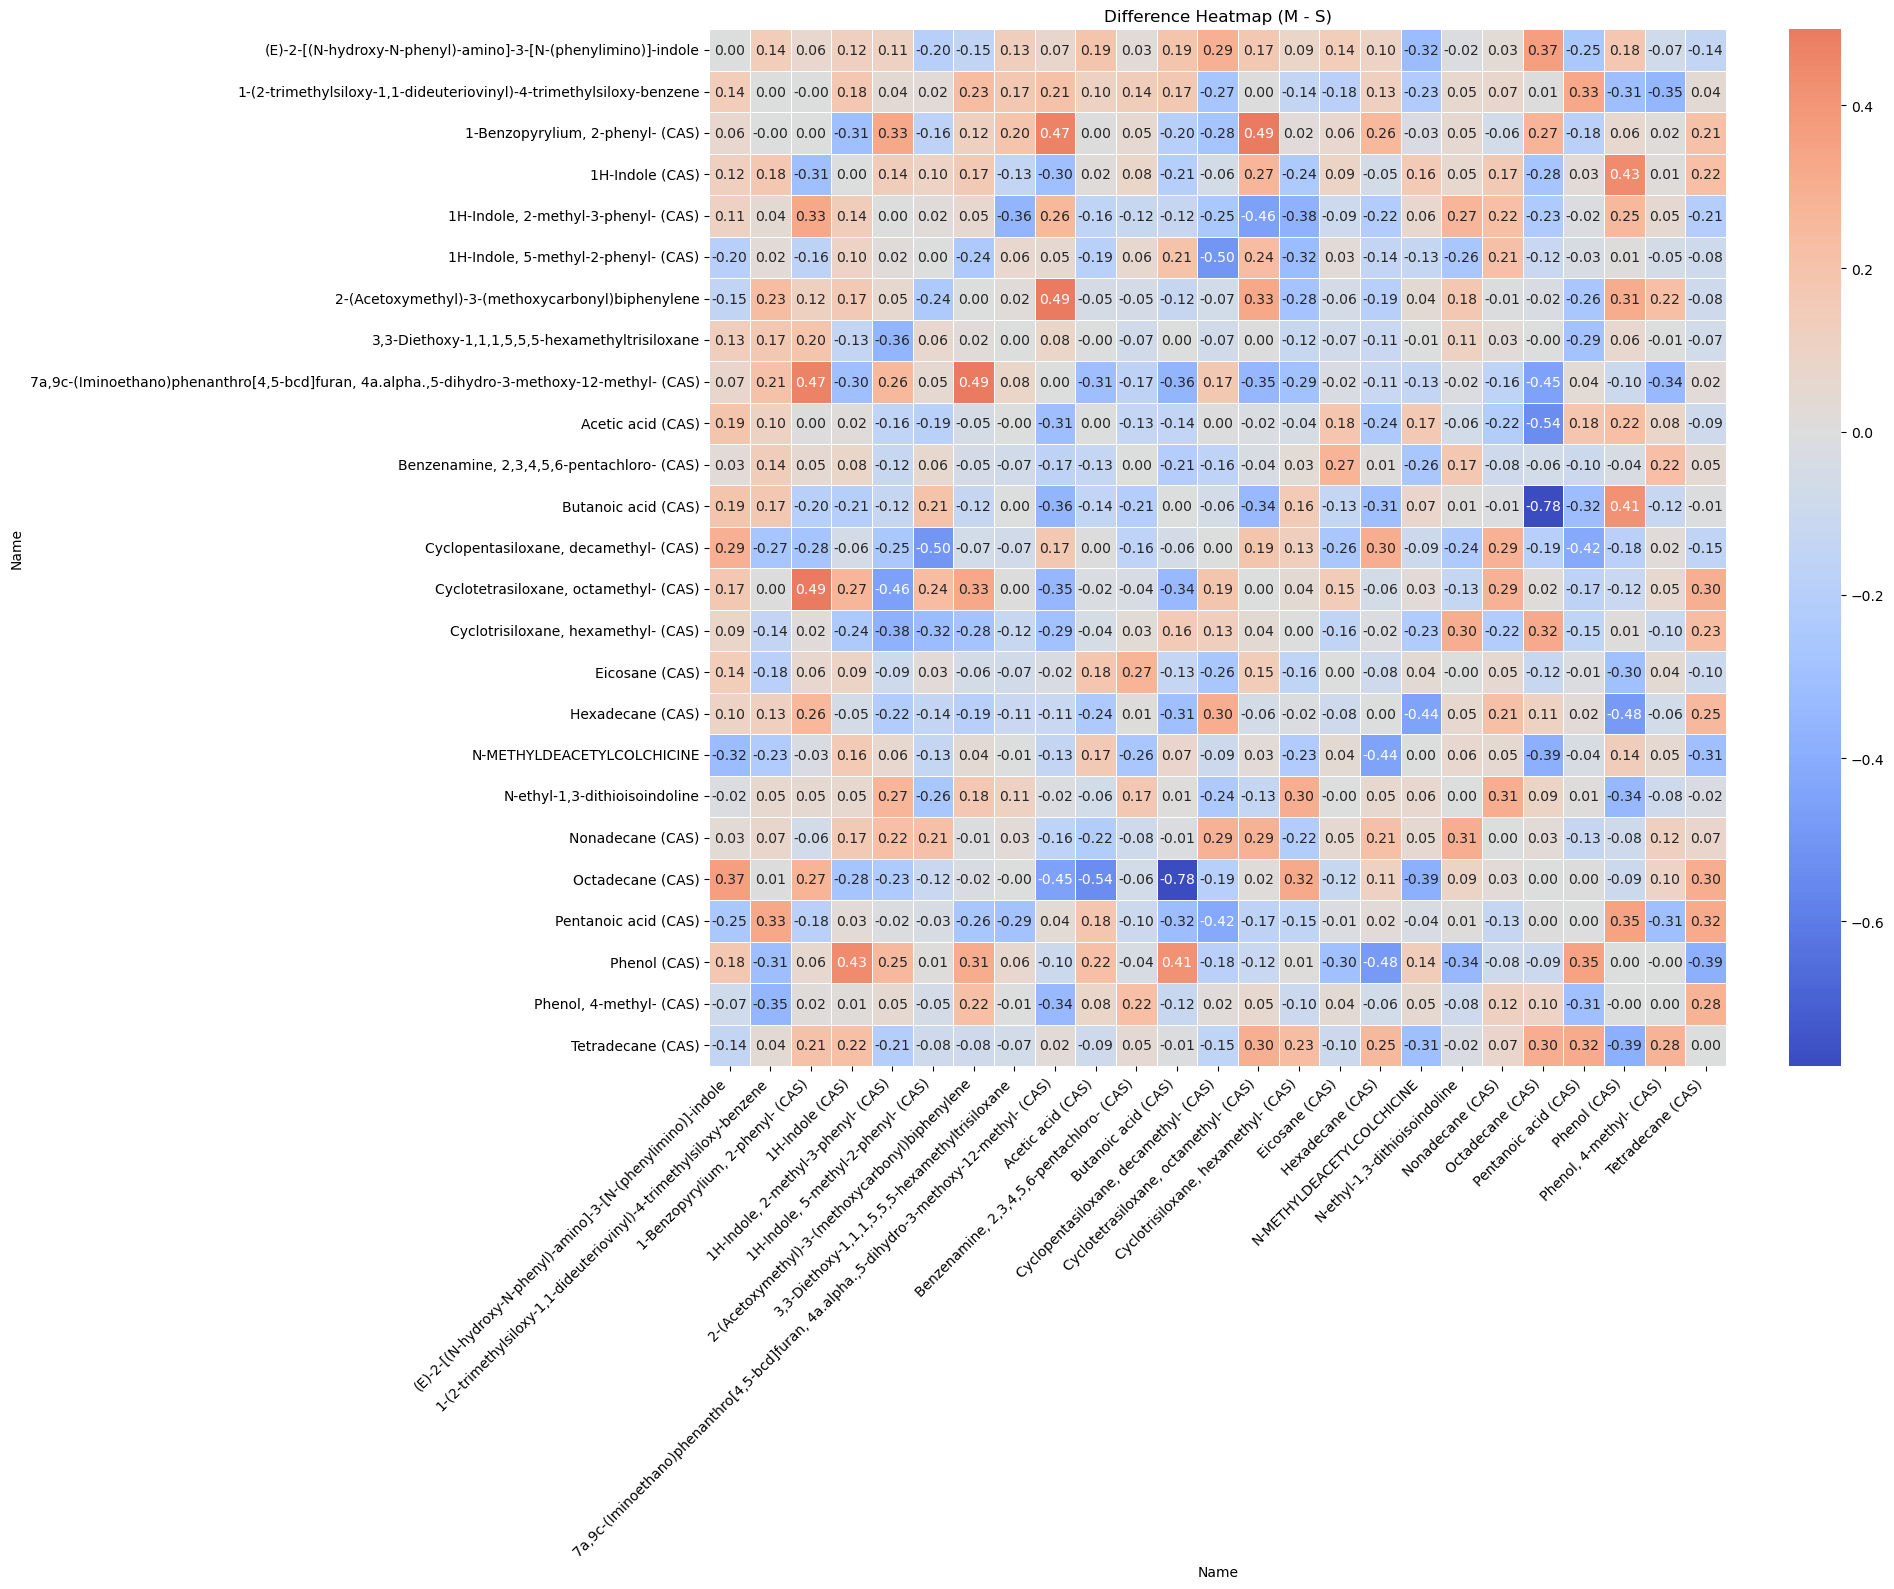

In [7]:
# Heatmap para diferencia entre S - M
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_diff, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('Difference Heatmap (M - S)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Diferencias de Correlación diferencia entre M - P
Esta celda genera mapas de calor (heatmaps) para visualizar las diferencias calculadas anteriormente. 

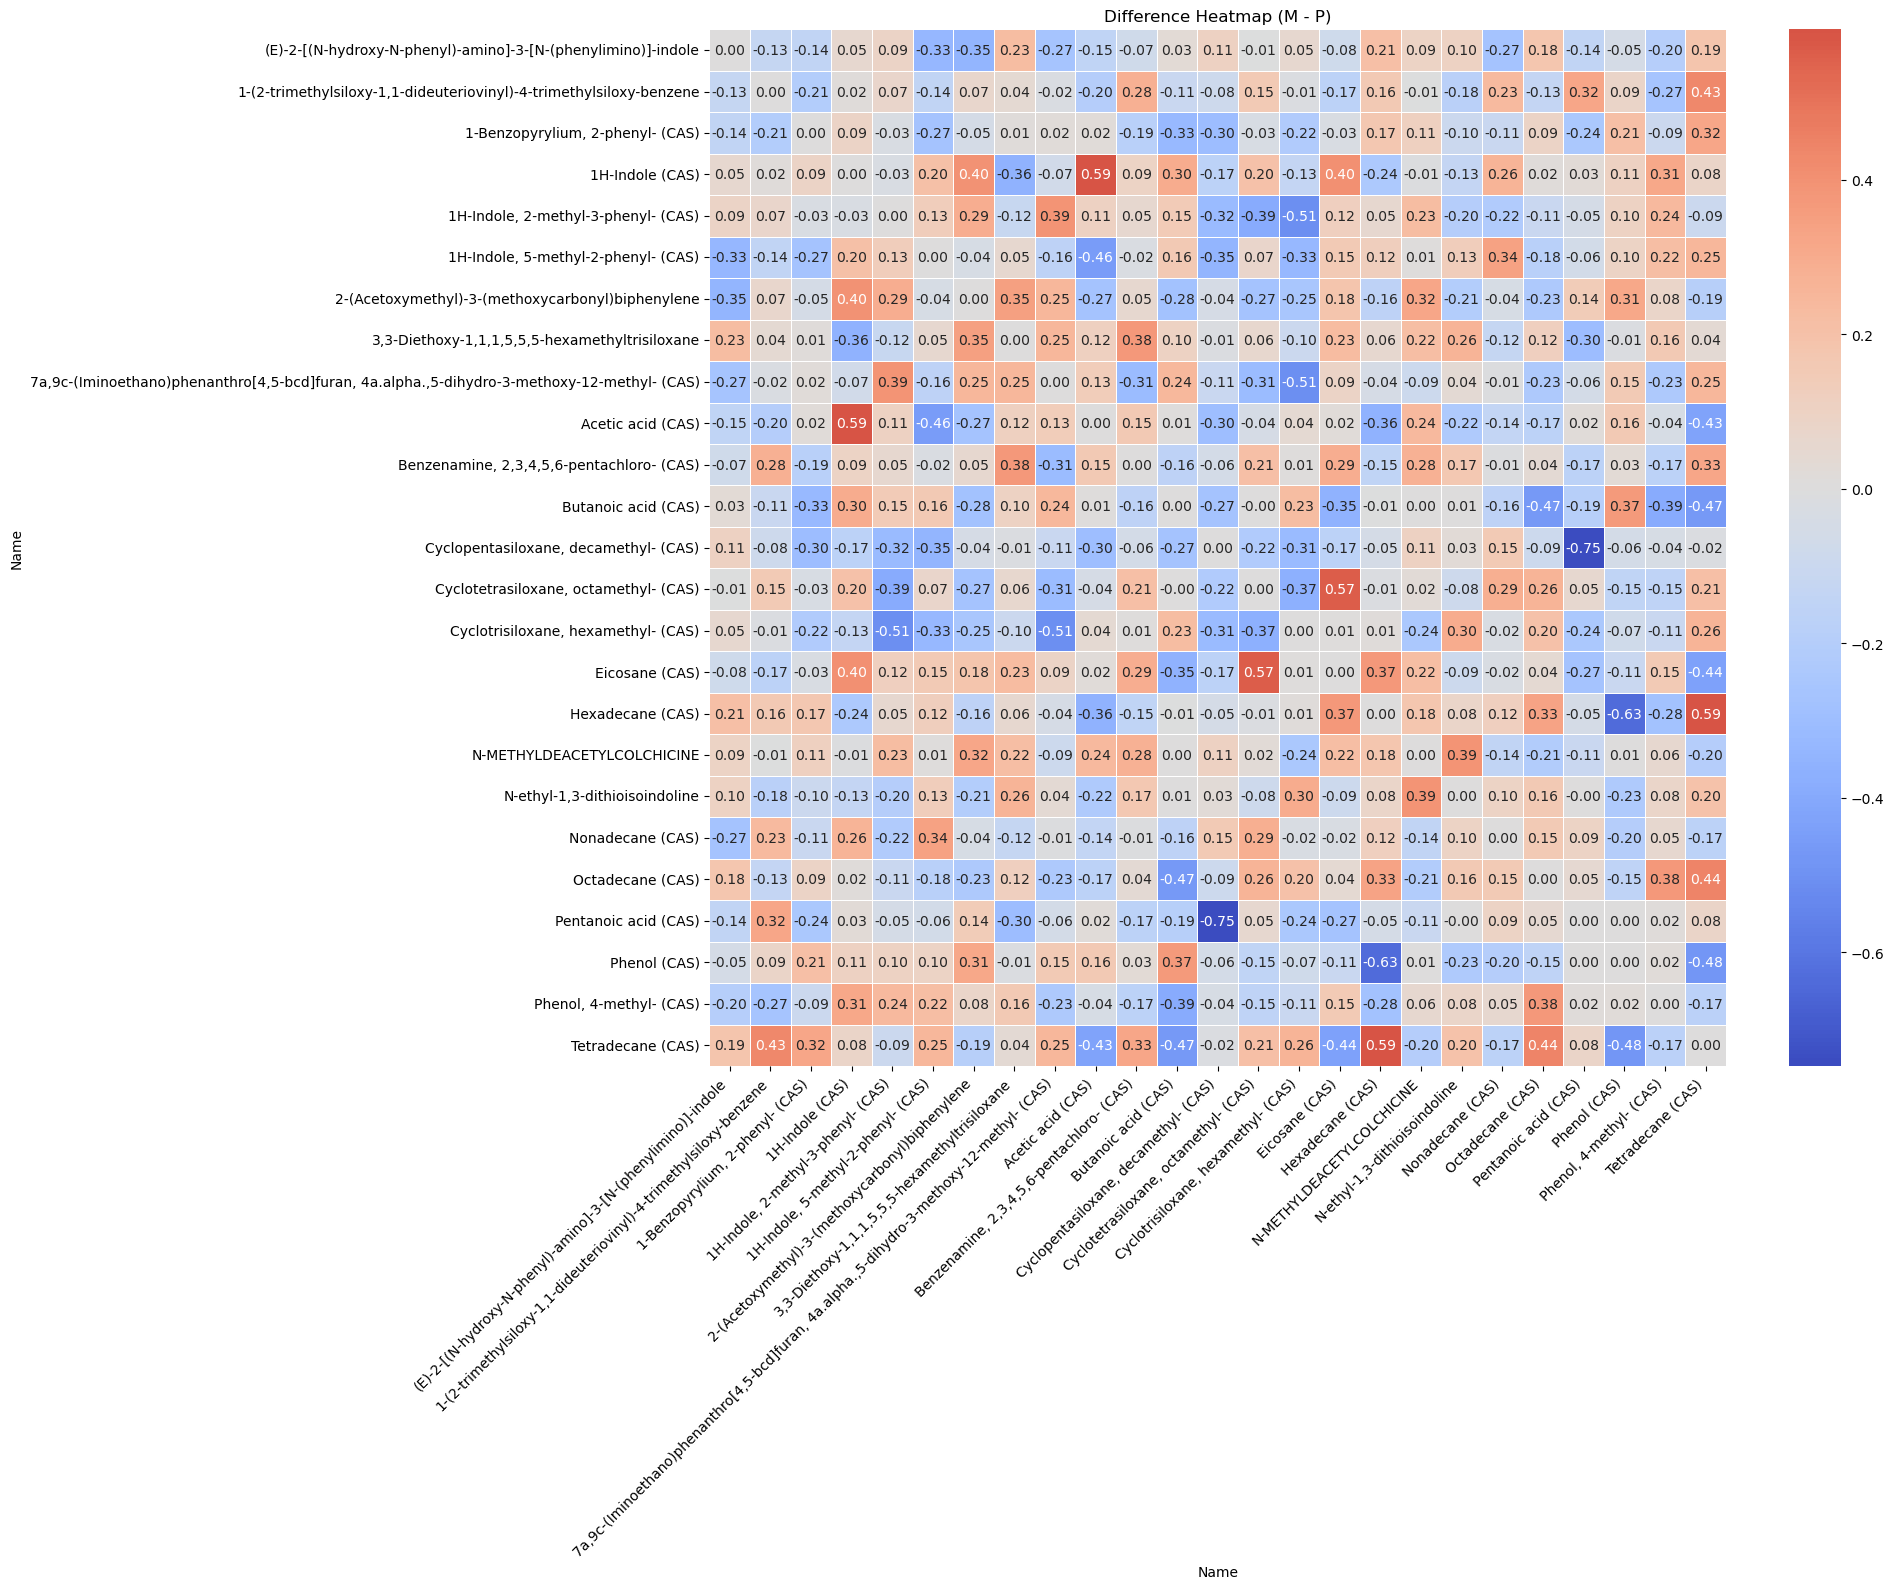

In [8]:
# Heatmap para diferencia entre (M - P)
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_diff_M_P, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('Difference Heatmap (M - P)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Diferencias de Correlación diferencia entre S - P
Esta celda genera mapas de calor (heatmaps) para visualizar las diferencias calculadas anteriormente. 

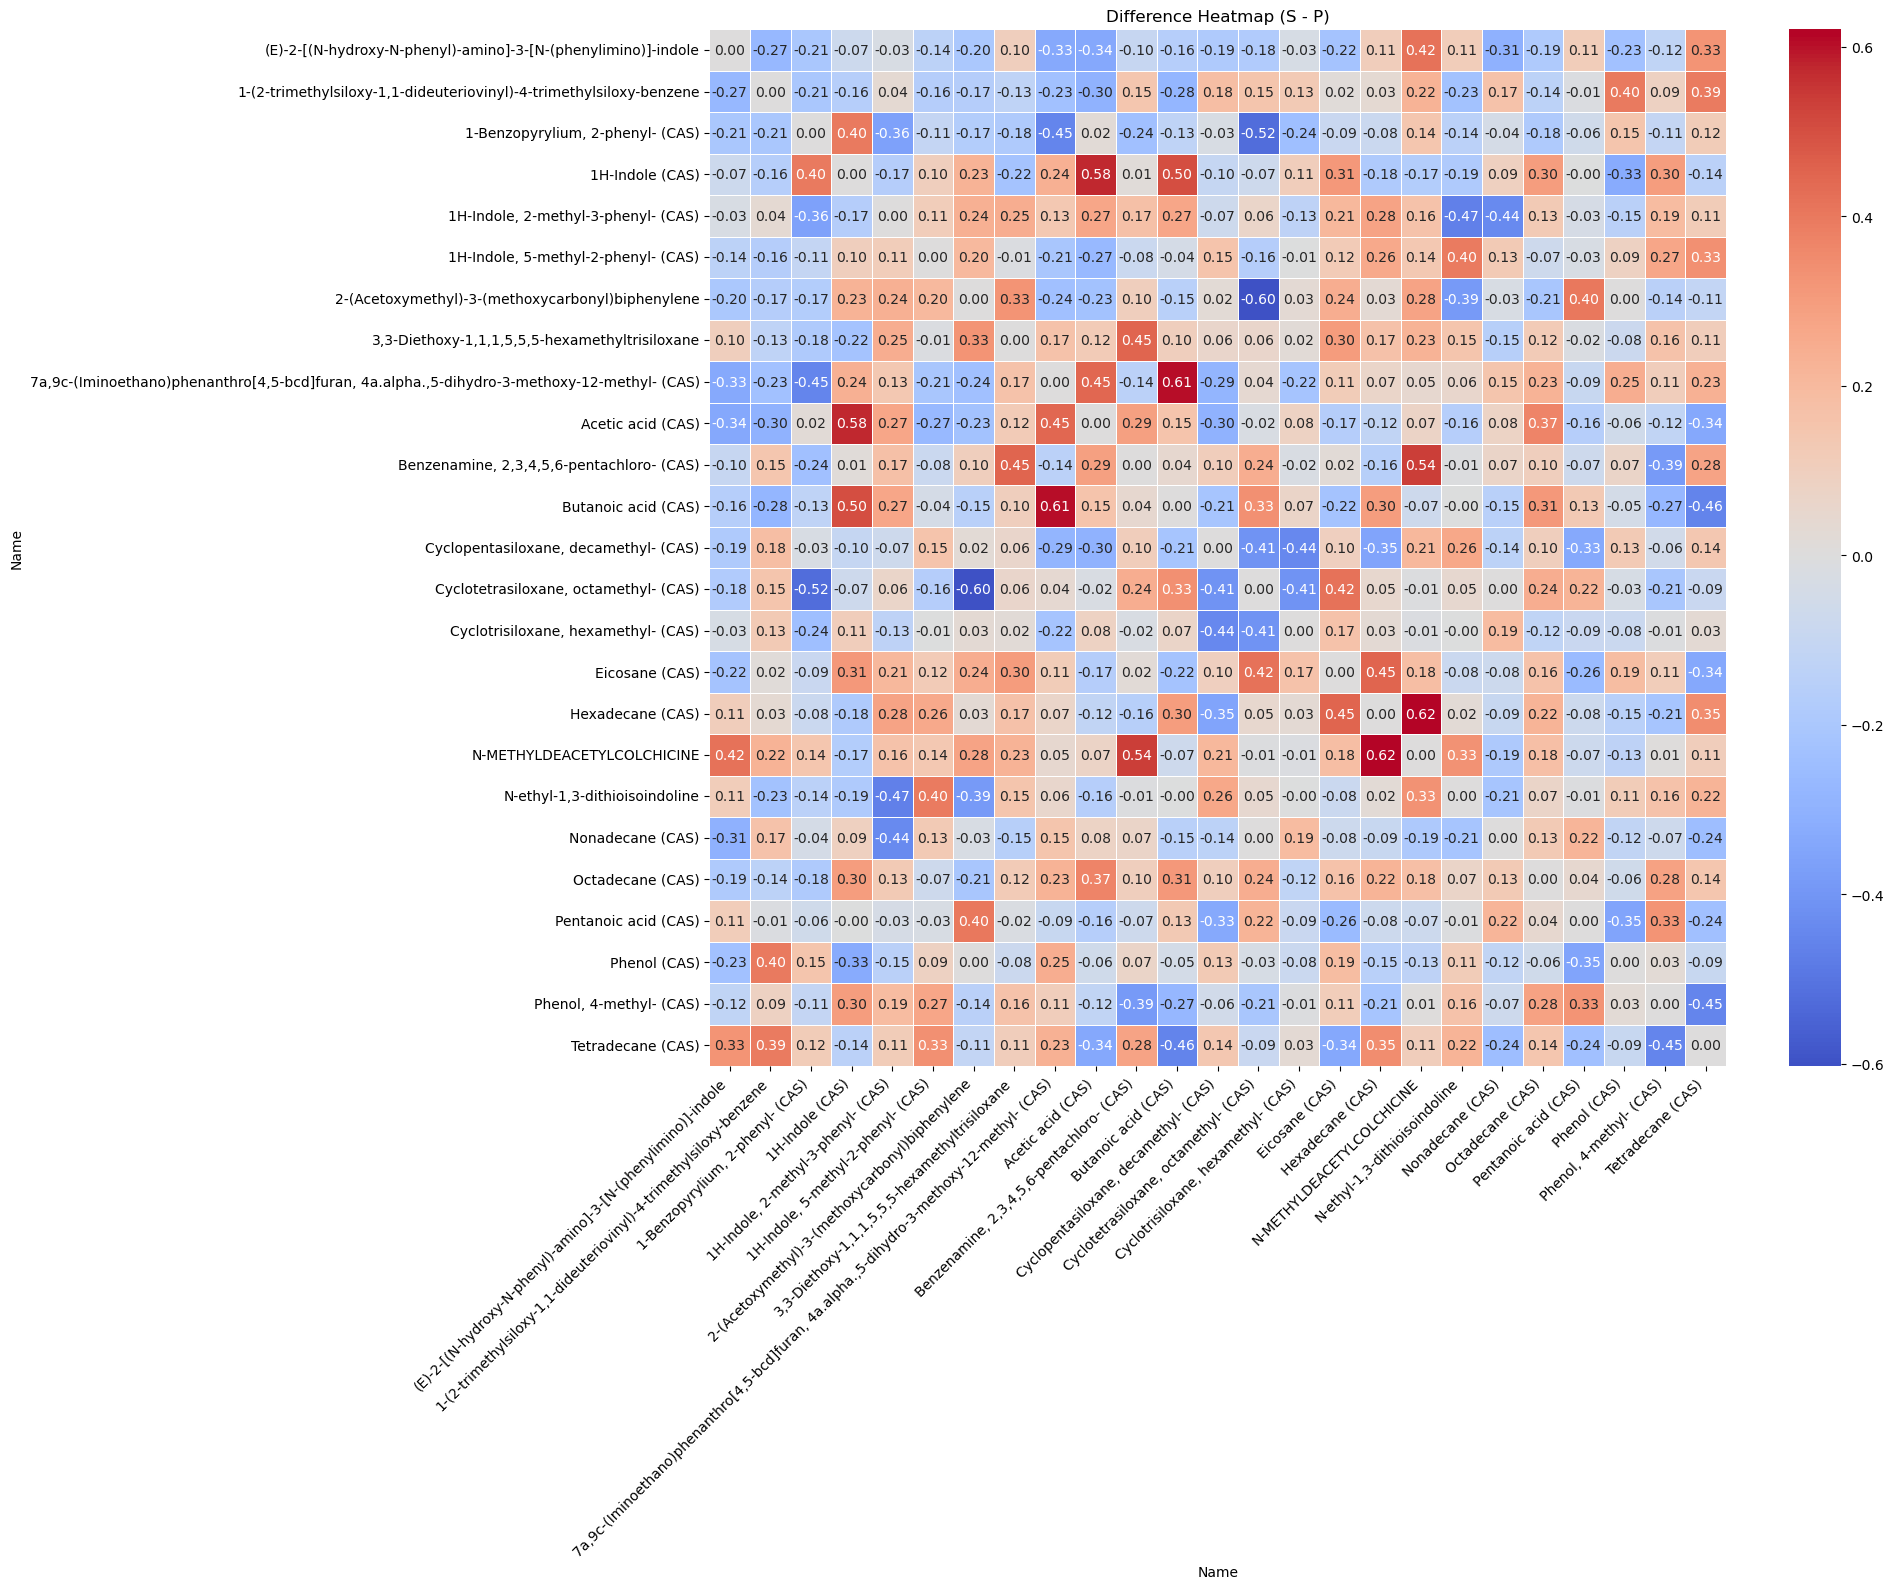

In [9]:
# Heatmap para diferencia entre (S - P)
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_diff_S_P, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('Difference Heatmap (S - P)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Filtrado de Variables por Umbral de Correlación (Población M)

En esta sección se identifican las variables que presentan las asociaciones más fuertes dentro del grupo (M)

In [10]:
CORRELATION_THRESHOLD = 0.3

# ------------------------ Seleccionar Nombres con |Correlación| > CORRELATION_THRESHOLD ------------------------

# Para la Población M
# Filtrar la matriz para obtener valores absolutos mayores o iguales al umbral
high_corr_m = correlation_matrix_m[correlation_matrix_m.abs() >= CORRELATION_THRESHOLD]

# Eliminar filas/columnas vacías para obtener la lista de nombres con alta correlación
names_high_corr_m = high_corr_m.dropna(how='all', axis=0).dropna(how='all', axis=1).columns.tolist()

# Contar ocurrencias en M
counts_m = grouped_m[grouped_m['Name'].isin(names_high_corr_m)].groupby('Name')['Count'].sum().to_dict()

# Imprimir encabezado en negrita
try:
    # Para Jupyter Notebooks
    display(HTML(f"<b>Nombres con |correlación| >= {CORRELATION_THRESHOLD} en la Población M:</b>"))
except:
    # Para Terminal/Consola
    print(f"\033[1mNombres con |correlación| >= {CORRELATION_THRESHOLD} en la Población M:\033[0m")

# Mostrar cada nombre y su conteo
for name in names_high_corr_m:
    display(Markdown(f"{name} - **{counts_m.get(name, 0)}**"))

(E)-2-[(N-hydroxy-N-phenyl)-amino]-3-[N-(phenylimino)]-indole - **19**

1-(2-trimethylsiloxy-1,1-dideuteriovinyl)-4-trimethylsiloxy-benzene - **29**

1-Benzopyrylium, 2-phenyl- (CAS) - **21**

1H-Indole (CAS) - **26**

1H-Indole, 2-methyl-3-phenyl- (CAS) - **19**

...

Octadecane (CAS) - **28**

Pentanoic acid (CAS) - **19**

Phenol (CAS) - **33**

Phenol, 4-methyl- (CAS) - **43**

Tetradecane (CAS) - **23**

### Filtrado de Variables por Umbral de Correlación (Población s)

En esta sección se identifican las variables que presentan las asociaciones más fuertes dentro del grupo (S)

In [11]:
# Para la Población S
# Filtrar la matriz para obtener valores absolutos de correlación mayores o iguales al umbral
high_corr_s = correlation_matrix_s[correlation_matrix_s.abs() >= CORRELATION_THRESHOLD]

# Eliminar filas/columnas vacías para obtener la lista de nombres con alta correlación
names_high_corr_s = high_corr_s.dropna(how='all', axis=0).dropna(how='all', axis=1).columns.tolist()

# Contar ocurrencias en S
counts_s = grouped_s[grouped_s['Name'].isin(names_high_corr_s)].groupby('Name')['Count'].sum().to_dict()

# Imprimir encabezado en negrita
try:
    # Para Jupyter Notebooks
    display(HTML(f"<b>Nombres con |correlación| >= {CORRELATION_THRESHOLD} en la Población S:</b>"))
except:
    # Para Terminal/Consola
    print(f"\033[1mNombres con |correlación| >= {CORRELATION_THRESHOLD} en la Población S:\033[0m")

# Mostrar cada nombre y su conteo correspondiente
for name in names_high_corr_s:
    display(Markdown(f"{name} - **{counts_s.get(name, 0)}**"))

(E)-2-[(N-hydroxy-N-phenyl)-amino]-3-[N-(phenylimino)]-indole - **15**

1-(2-trimethylsiloxy-1,1-dideuteriovinyl)-4-trimethylsiloxy-benzene - **23**

1-Benzopyrylium, 2-phenyl- (CAS) - **9**

1H-Indole (CAS) - **14**

1H-Indole, 2-methyl-3-phenyl- (CAS) - **9**

...

Octadecane (CAS) - **21**

Pentanoic acid (CAS) - **16**

Phenol (CAS) - **24**

Phenol, 4-methyl- (CAS) - **42**

Tetradecane (CAS) - **22**

### Filtrado de Variables por Umbral de Correlación (Población P)

En esta sección se identifican las variables que presentan las asociaciones más fuertes dentro del grupo (P)

In [12]:
# Para la Población P
# Filtrar la matriz para obtener valores absolutos de correlación mayores o iguales al umbral
high_corr_p = correlation_matrix_p[correlation_matrix_p.abs() >= CORRELATION_THRESHOLD]

# Eliminar filas/columnas vacías para obtener la lista de nombres con alta correlación
names_high_corr_p = high_corr_p.dropna(how='all', axis=0).dropna(how='all', axis=1).columns.tolist()

# Contar ocurrencias en P
counts_p = grouped_p[grouped_p['Name'].isin(names_high_corr_p)].groupby('Name')['Count'].sum().to_dict()

# Imprimir encabezado en negrita
try:
    # Para Jupyter Notebooks
    display(HTML(f"<b>Nombres con |correlación| >= {CORRELATION_THRESHOLD} en la Población P:</b>"))
except:
    # Para Terminal/Consola
    print(f"\033[1mNombres con |correlación| >= {CORRELATION_THRESHOLD} en la Población P:\033[0m")

# Mostrar cada nombre y su conteo correspondiente
for name in names_high_corr_p:
    display(Markdown(f"{name} - **{counts_p.get(name, 0)}**"))

(E)-2-[(N-hydroxy-N-phenyl)-amino]-3-[N-(phenylimino)]-indole - **5**

1-(2-trimethylsiloxy-1,1-dideuteriovinyl)-4-trimethylsiloxy-benzene - **9**

1-Benzopyrylium, 2-phenyl- (CAS) - **7**

1H-Indole (CAS) - **17**

1H-Indole, 2-methyl-3-phenyl- (CAS) - **8**

...

Octadecane (CAS) - **27**

Pentanoic acid (CAS) - **14**

Phenol (CAS) - **21**

Phenol, 4-methyl- (CAS) - **38**

Tetradecane (CAS) - **11**

### Análisis de Diferencias de Correlación (M vs S)

En este bloque se identifican las variaciones más significativas en el comportamiento de las variables al comparar el grupo  (**M**) con el grupo (**S**).

In [13]:
# Para Diferencias (M - S)
# Filtrar donde tanto la población S como la M superan el umbral de valor absoluto
high_diff = correlation_diff[(correlation_matrix_s.abs() >= CORRELATION_THRESHOLD) & (correlation_matrix_m.abs() >= CORRELATION_THRESHOLD)]

# Obtener la lista de nombres que cumplen con los criterios de alta diferencia/correlación
names_high_diff = high_diff.dropna(how='all', axis=0).dropna(how='all', axis=1).columns.tolist()

# Imprimir encabezado en negrita
try:
    # Para Jupyter Notebooks
    display(HTML(f"<b>Nombres con |diferencia de correlación| >= {CORRELATION_THRESHOLD}:</b>"))
except:
    # Para Terminal/Consola
    print(f"\033[1mNombres con |diferencia de correlación| >= {CORRELATION_THRESHOLD}:\033[0m")
    
# Mostrar resultados con formato de color según el valor de la correlación
for name in names_high_diff:
    count_m = counts_m.get(name, 0)
    count_s = counts_s.get(name, 0)
    correlation = correlation_diff.loc[:, name].mean()  # Usar la correlación media
    # Azul para diferencias negativas, rojo para positivas
    color = 'blue' if correlation < 0 else 'red'
    display(HTML(f"<span style='color:{color}'>{name}</span> - M: <b>{count_m}</b>, S: <b>{count_s}</b>"))

### Análisis de Diferencias de Correlación (M vs p)

En este bloque se identifican las variaciones más significativas en el comportamiento de las variables al comparar el grupo  (**M**) con el grupo (**P**).

In [14]:
# Para Diferencias (M - P)
# Filtrar donde tanto la población P como la M superan el umbral de valor absoluto
high_diff = correlation_diff[(correlation_matrix_p.abs() >= CORRELATION_THRESHOLD) & (correlation_matrix_m.abs() >= CORRELATION_THRESHOLD)]

# Obtener la lista de nombres que cumplen con los criterios de alta diferencia/correlación
names_high_diff = high_diff.dropna(how='all', axis=0).dropna(how='all', axis=1).columns.tolist()

# Imprimir encabezado en negrita
try:
    # Para Jupyter Notebooks
    display(HTML(f"<b>Nombres con |diferencia de correlación| >= {CORRELATION_THRESHOLD}:</b>"))
except:
    # Para Terminal/Consola
    print(f"\033[1mNombres con |diferencia de correlación| >= {CORRELATION_THRESHOLD}:\033[0m")
    
# Mostrar resultados con formato de color según el valor de la correlación
for name in names_high_diff:
    count_m = counts_m.get(name, 0)
    count_p = counts_p.get(name, 0)
    correlation = correlation_diff_M_P.loc[:, name].mean()  # Usar la correlación media
    # Azul para diferencias negativas, rojo para positivas
    color = 'blue' if correlation < 0 else 'red'
    display(HTML(f"<span style='color:{color}'>{name}</span> - M: <b>{count_m}</b>, P: <b>{count_p}</b>"))

### Análisis de Diferencias de Correlación (S vs P)

En este bloque se identifican las variaciones más significativas en el comportamiento de las variables al comparar el grupo  (**S**) con el grupo (**P**).

In [15]:
# Para Diferencias (S - P)
# Filtrar donde tanto la población P como la S superan el umbral de valor absoluto
high_diff = correlation_diff[(correlation_matrix_p.abs() >= CORRELATION_THRESHOLD) & (correlation_matrix_s.abs() >= CORRELATION_THRESHOLD)]

# Obtener la lista de nombres que cumplen con los criterios de alta diferencia/correlación
names_high_diff = high_diff.dropna(how='all', axis=0).dropna(how='all', axis=1).columns.tolist()

# Imprimir encabezado en negrita
try:
    # Para Jupyter Notebooks
    display(HTML(f"<b>Nombres con |diferencia de correlación| >= {CORRELATION_THRESHOLD}:</b>"))
except:
    # Para Terminal/Consola
    print(f"\033[1mNombres con |diferencia de correlación| >= {CORRELATION_THRESHOLD}:\033[0m")
    
# Mostrar resultados con formato de color según el valor de la correlación
for name in names_high_diff:
    count_s = counts_s.get(name, 0)
    count_p = counts_p.get(name, 0)
    correlation = correlation_diff_S_P.loc[:, name].mean()  # Usar la correlación media
    # Azul para diferencias negativas, rojo para positivas
    color = 'blue' if correlation < 0 else 'red'
    display(HTML(f"<span style='color:{color}'>{name}</span> - S: <b>{count_s}</b>, P: <b>{count_p}</b>"))